<a href="https://colab.research.google.com/github/sschares/ores5160-2026/blob/main/Schares_ORES5160_2026_Week_9_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/ORES5160/

est2018-pop-res.csv  patient.json


In [5]:
%%bash
head /content/drive/MyDrive/ORES5160/est2018-pop-res.csv

SUMLEV,REGION,DIVISION,STATE,NAME,POPESTIMATE2018,POPEST18PLUS2018,PCNT_POPEST18PLUS
010,0,0,00,United States,327167434,253768092,77.6
040,3,6,01,Alabama,4887871,3798031,77.7
040,4,9,02,Alaska,737438,553622,75.1
040,4,8,04,Arizona,7171646,5528989,77.1
040,3,7,05,Arkansas,3013825,2310645,76.7
040,4,9,06,California,39557045,30567090,77.3
040,4,8,08,Colorado,5695564,4430329,77.8
040,1,1,09,Connecticut,3572665,2837472,79.4
040,3,5,10,Delaware,967171,763555,78.9


In [6]:
import csv

In [7]:
#1A: Open CSV file and print first 5 lines
with open("/content/drive/MyDrive/ORES5160/est2018-pop-res.csv", 'r') as f:
  csv_reader = csv.reader(f)
  counter = 0
  max_lines = 5
  for row in csv_reader:
    print(row)
    counter += 1
    if counter > max_lines:
      break

['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']
['010', '0', '0', '00', 'United States', '327167434', '253768092', '77.6']
['040', '3', '6', '01', 'Alabama', '4887871', '3798031', '77.7']
['040', '4', '9', '02', 'Alaska', '737438', '553622', '75.1']
['040', '4', '8', '04', 'Arizona', '7171646', '5528989', '77.1']
['040', '3', '7', '05', 'Arkansas', '3013825', '2310645', '76.7']


In [8]:
import pandas as pd

In [9]:
#1B: Load CSV file into a dataframe
df = pd.read_csv('/content/drive/MyDrive/ORES5160/est2018-pop-res.csv')

In [10]:
#1C: Display dataframe shape
print(df.shape)

(53, 8)


In [11]:
#1D: Print column names
list(df.columns)

['SUMLEV',
 'REGION',
 'DIVISION',
 'STATE',
 'NAME',
 'POPESTIMATE2018',
 'POPEST18PLUS2018',
 'PCNT_POPEST18PLUS']

In [12]:
#1E: List total population column and 5 most populous states
# POPESTIMATE2018 refers to the total population. POPEST18PLUS2018, I assume, refers only to adults (a subset of the total population)

# Filter for state-level data (SUMLEV = 40) and sort by POPESTIMATE2018
# The SUMLEV column with value 40 typically indicates state-level data.
most_populous_states = df[df['SUMLEV'] == 40].sort_values(by='POPESTIMATE2018', ascending=False)

# Display the top 5 states by name and population
print("Top 5 most populous states:")
print(most_populous_states[['NAME', 'POPESTIMATE2018']].head(5))

Top 5 most populous states:
            NAME  POPESTIMATE2018
5     California         39557045
44         Texas         28701845
10       Florida         21299325
33      New York         19542209
39  Pennsylvania         12807060


In [13]:
#2A: Compute average state population
df[df['SUMLEV'] == 40]['POPESTIMATE2018'].mean()

np.float64(6353126.673076923)

In [14]:
#2B: Which region has the highest total population
df[df['SUMLEV'] == 40].groupby("REGION")['POPESTIMATE2018'].sum()

# Region 3 has the highest total population

,POPESTIMATE2018
REGION,
1,56111079
2,68308744
3,124753948
4,77993663
X,3195153


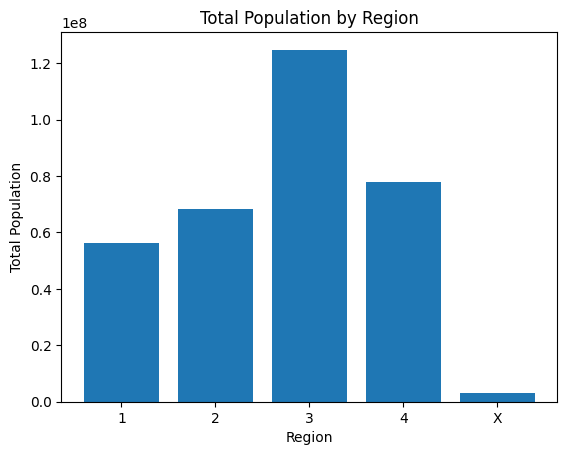

In [15]:
#2C: Plot a bar chart of regional population
import matplotlib.pyplot as plt

regional_population = df[df['SUMLEV'] == 40].groupby("REGION")['POPESTIMATE2018'].sum()

plt.bar(x=regional_population.index, height=regional_population.values)
plt.xlabel("Region")
plt.ylabel("Total Population")
plt.title("Total Population by Region")
plt.show()

In [16]:
#3A: Load patient.json into Python dictionary
import json

with open("/content/drive/MyDrive/ORES5160/patient.json") as p:
  data = json.load(p)
  print(data)
  print(type(data))

{'resourceType': 'Patient', 'id': 'example', 'identifier': [{'use': 'usual', 'type': {'coding': [{'system': 'http://terminology.hl7.org/CodeSystem/v2-0203', 'code': 'MR'}]}, 'system': 'urn:oid:1.2.36.146.595.217.0.1', 'value': '12345', 'period': {'start': '2001-05-06'}, 'assigner': {'display': 'Acme Healthcare'}}], 'active': True, 'name': [{'use': 'official', 'family': 'Chalmers', 'given': ['Peter', 'James']}, {'use': 'usual', 'given': ['Jim']}, {'use': 'maiden', 'family': 'Windsor', 'given': ['Peter', 'James'], 'period': {'end': '2002'}}], 'telecom': [{'use': 'home'}, {'system': 'phone', 'value': '(03) 5555 6473', 'use': 'work', 'rank': 1}, {'system': 'phone', 'value': '(03) 3410 5613', 'use': 'mobile', 'rank': 2}, {'system': 'phone', 'value': '(03) 5555 8834', 'use': 'old', 'period': {'end': '2014'}}], 'gender': 'male', 'birthDate': '1974-12-25', '_birthDate': {'extension': [{'url': 'http://hl7.org/fhir/StructureDefinition/patient-birthTime', 'valueDateTime': '1974-12-25T14:35:45-05:

In [17]:
#3B: Extract and print patient's full official name

# The 'name' key contains a list of name objects, typically the first one is the official name.
official_name_entry = data['name'][0]

# Extract given names (which can be a list) and family name
given_names = " ".join(official_name_entry.get('given', []))
family_name = official_name_entry.get('family', '')

full_official_name = f"{given_names} {family_name}".strip()
print(f"Patient's full official name: {full_official_name}")

Patient's full official name: Peter James Chalmers


In [18]:
#3C: Extract and print gender and birthdate
gender = data['gender']
birthdate = data['birthDate']
print(f"Patient's gender: {gender}")
print(f"Patient's birthdate: {birthdate}")


Patient's gender: male
Patient's birthdate: 1974-12-25


In [22]:
#3D: Extract and print current address
current_address = data['address'][0]
text = current_address.get('text', '')
print(f"Patient's current address: {text}")

Patient's current address: 534 Erewhon St PeasantVille, Rainbow, Vic  3999


In [23]:
#3E: Count distinct phone numbers and list type
# Filter out entries where 'value' is null or empty
filtered_telecom_entries = [phone for phone in data.get('telecom', []) if phone.get('value')]

phone_numbers = (phone['value'] for phone in filtered_telecom_entries)
unique_phone_numbers = set(phone_numbers)
print(f"Distinct phone numbers: {len(unique_phone_numbers)}")
print(f"Phone numbers: {unique_phone_numbers}")
print(f"Types of phone numbers: {set(phone.get('use', '') for phone in filtered_telecom_entries)}")

Distinct phone numbers: 3
Phone numbers: {'(03) 3410 5613', '(03) 5555 8834', '(03) 5555 6473'}
Types of phone numbers: {'old', 'mobile', 'work'}
